In [33]:
# load settings
import re
import typing as t
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit

np.random.seed(42)  # For reproducibility
data_root = "/Users/jliu/workspace/lexical_bencmark/dataset"

# plotting style configuration and data loading



In [88]:
# Type aliases
DataFrameType = pd.DataFrame
PathType = Path | str


class PlotSettings:
    """Unified plotting settings and styling configuration."""
    COLORS: dict[str, str] = {
        "human_CDI": "#d62728",
        "CHILDES": "orange",
        "stela": "blue",
        "child": "green",
    }

    LINESTYLES: dict[str, str] = {
        "CHILDES": "-", 
        "child": "-", 
        "LSTM": "-", 
        "trans": "-."}

    DEFAULTS: dict[str, t.Any] = {
        "label_fontsize": 18, 
        "linewidth": 3, 
        "title_fontsize": 28, 
        "grid_color": "#bbbbbb", 
        "figsize": (10, 6), 
        "default_fill_alpha": 0.25
        }
    FILL_ALPHA: dict[str, float] = {
        "before": 0.1,
        "after": 0.5,
        }

    @staticmethod
    def configure_plot(title: str | None = None, model: str | None = None) -> None:
        """Configure basic plot settings."""
        if title or model:
            plt.title(title or model, fontsize=PlotSettings.DEFAULTS["label_fontsize"], fontweight="bold")
        plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"])

    @staticmethod
    def configure_legend() -> None:
        """Configure legend settings."""
        plt.legend(
            title="Settings", title_fontsize=PlotSettings.DEFAULTS["title_fontsize"], fontsize=PlotSettings.DEFAULTS["label_fontsize"], loc="upper left", bbox_to_anchor=(1.01, 1)
        )

    @staticmethod
    def save_figure(filepath: str) -> None:
        """Save the current figure to file."""
        plt.tight_layout()
        plt.savefig(filepath, bbox_inches="tight")
        plt.close()

    @staticmethod
    def get_color_palette(n_colors: int) -> list[str]:
        """Get a color palette for the given number of colors."""
        return sns.color_palette("husl", n_colors=n_colors).as_hex()

    @staticmethod
    def apply_style_to_axis(ax: plt.Axes, title: str | None = None) -> None:
        """Apply styling to an existing axis."""
        if title:
            ax.set_title(title, fontsize=PlotSettings.DEFAULTS["title_fontsize"])
        ax.tick_params(labelsize=PlotSettings.DEFAULTS["label_fontsize"])
        ax.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"])


class DataLoader:
    """Unified data loading and preprocessing functionality."""

    @staticmethod
    def get_freq(df: DataFrameType) -> DataFrameType:
        """Annotate frequency of the given column."""
        df = df.copy()
        if "freq" not in df.columns:
            df["freq"] = (df["count"] / df["count"].sum()) * 1_000_000
        df["log_freq"] = np.log10(df["freq"] + 1e-10)
        return df.dropna()

    @staticmethod
    def load_df(df: DataFrameType, metric: str) -> DataFrameType:
        """Load and aggregate data based on metric while handling duplicates."""
        df = df.copy()
        # Filter temperature
        df = df[df["temp"] == 1.0]

        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

        if metric != "CDI":
            df[metric] = df[metric].fillna(method="ffill")
            df = (
                df.groupby(["condition", metric])
                .agg({"dataset": "first", "model_type": "first", "temp": "first", "word_num": "mean", "chunk": "first", "month": "last"})
                .reset_index()
            )
        return df

    @staticmethod
    def calculate_statistics(df: DataFrameType, group_header: str, x_header: str, y_header: str | None = None) -> DataFrameType:
        """Calculate mean, standard deviation, and confidence intervals."""
        df = df.copy()
        if y_header is None:
            stats = df.groupby([group_header, x_header]).agg(["mean", "std", "count"]).reset_index()
        else:
            stats = df.groupby([group_header, x_header])[y_header].agg(["mean", "std", "count"]).reset_index()

        stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        return stats


def extract_style(text: str) -> str:
    """Extract text inside parentheses."""
    match = re.search(r"\((.*?)\)", text)
    return match.group(1) if match else ""

# plotting functions

In [ ]:
class DistrBuilder:
    """Builder class for creating various types of plots."""

    def __init__(self, df: pd.DataFrame,column: str,color: str, name: str, fill_alpha:float):
        """Initialize with a DataFrame."""
        self.df = df
        self.column = column
        self.color = color
        self.name = name
        self.fill_alpha = fill_alpha


    def _calculate_bin_edges(self, bin_header: str) -> list[float]:
        """Calculate bin edges for histogram."""
        data_grouped = self.df.groupby(bin_header)
        bin_edges = [self.df[self.column].min()]
        for _, group_data in data_grouped:
            bin_edges.append(group_data[self.column].max())
        return bin_edges

    def plot_histogram(
        self,
        bin_header: str | None
    ) -> None:
        """Plot histogram for given data."""
        df_sorted = self.df.sort_values(by=self.column, ascending=True)
        if bin_header:
            bin_edges = self._calculate_bin_edges(self.column, bin_header)
            plt.hist(
                df_sorted[self.column],
                bins=bin_edges,
                alpha=self.fill_alpha,
                color=self.color,
                edgecolor=self.color,
                linestyle=PlotSettings.LINESTYLES.get(self.name, "-"),
                label=self.name,
                density=True
            )
        else:
            plt.hist(
                df_sorted[self.column],
                bins="auto",
                alpha=self.fill_alpha,
                color=self.color,
                edgecolor=self.color,
                linestyle=PlotSettings.LINESTYLES.get(self.name, "-"),
                label=self.name,
                density=True
            )

    def plot_kde(
        self
    ) -> None:
        """Plot KDE for given data."""
        sns.kdeplot(
            data=self.df[self.column],
            color=self.color,
            linestyle=PlotSettings.LINESTYLES.get(self.name, "-"),
            label=self.name,
            linewidth=PlotSettings.DEFAULTS["linewidth"],
            fill=True,
            alpha=self.fill_alpha
        )


In [92]:
def plot_distributions(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    bin_header: str | None = None,
    output_path: Path | None = None,
    kind: t.Literal["hist", "kde"] = "kde",
    title: str | None = None,
) -> None:
    """Plot distributions of a specific column from multiple dataframes."""
    plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])

    for name, df in dataframes.items():
        color = PlotSettings.COLORS.get(name.split("_")[0], "gray")
        fill_alpha = PlotSettings.FILL_ALPHA.get(name.split("_")[1], PlotSettings.DEFAULTS["default_fill_alpha"])

        if kind == "hist":
            plot_histogram(df, column, bin_header, color, fill_alpha, name)
        else:
            plot_kde(df, column, color, name, fill_alpha)

    configure_plot_style(column, title)

    if output_path:
        plt.savefig(output_path, bbox_inches="tight", dpi=300)
        plt.close()
    else:
        plt.show()


def plot_histogram(df: pd.DataFrame, column: str, bin_header: str | None, color: str, fill_alpha: float, name: str) -> None:
    """Plot histogram for given data."""
    df = df.sort_values(by=column, ascending=True)
    if bin_header:
        bin_edges = calculate_bin_edges(df, column, bin_header)
        plt.hist(df[column], bins=bin_edges, alpha=fill_alpha, color=color, edgecolor=color, linestyle=PlotSettings.LINESTYLES.get(name, "-"), label=name, density=True)
    else:
        plt.hist(df[column], bins="auto", alpha=fill_alpha, color=color, edgecolor=color, linestyle=PlotSettings.LINESTYLES.get(name, "-"), label=name, density=True)


def calculate_bin_edges(df: pd.DataFrame, column: str, bin_header: str) -> list[float]:
    """Calculate bin edges for histogram."""
    data_grouped = df.groupby(bin_header)
    bin_edges = [df[column].min()]

    for _, group_data in data_grouped:
        bin_edges.append(group_data[column].max())

    return bin_edges


def plot_kde(df: pd.DataFrame, column: str, color: str, name: str, fill_alpha: float) -> None:
    """Plot KDE for given data."""
    sns.kdeplot(
        data=df[column],
        color=color,
        linestyle=PlotSettings.LINESTYLES.get(name, "-"),
        label=name,
        linewidth=PlotSettings.DEFAULTS["linewidth"],
        fill=True,
        alpha=fill_alpha,
    )




def configure_plot_style(column: str, title: str | None = None) -> None:
    """Configure plot styling."""
    plt.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"], alpha=0.7)
    plt.xlabel(column, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel("Density", fontsize=PlotSettings.DEFAULTS["label_fontsize"])

    if title:
        plt.title(title, fontsize=PlotSettings.DEFAULTS["title_fontsize"], pad=20)

    plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.legend(
        title="Dataset",
        title_fontsize=PlotSettings.DEFAULTS["label_fontsize"],
        fontsize=PlotSettings.DEFAULTS["label_fontsize"],
        framealpha=0.9,
        edgecolor="black",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
    )
    plt.figure(figsize=(12, 6))
    plt.tight_layout()


def plot_curves(df: pd.DataFrame, x_header: str, y_header: str, group_header: str, y_lim: list[float] = [0, 1]) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    PlotSettings.configure_plot()
    df_stats = DataLoader.calculate_statistics(df, group_header, x_header, y_header)

    unique_conditions = df_stats[group_header].unique()
    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_curve(subset, condition, x_header)

    plt.ylim(y_lim)
    plt.xlabel(x_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    PlotSettings.configure_legend()
    plt.show()


def plot_condition_curve(subset: pd.DataFrame, condition: str, x_header: str) -> None:
    """Plot curve for a single condition with confidence interval."""
    base_condition = condition.split("(")[0]
    color = PlotSettings.COLORS[base_condition]

    plt.plot(
        subset[x_header],
        subset["mean"],
        label=condition,
        color=color,
        linestyle=PlotSettings.LINESTYLES.get(extract_style(condition), "-"),
        linewidth=PlotSettings.DEFAULTS["linewidth"],
    )

    plt.fill_between(subset[x_header], subset["mean"] - subset["ci"], subset["mean"] + subset["ci"], color=color, alpha=0.2)


# Freq match

In [99]:
def compare_freq(file_root: Path, freq_root: Path, cdi_path: Path, output_dir: Path | None = None) -> None:
    """Compare frequency distributions before and after matching."""
    # Load raw datasets
    childes = DataLoader.get_freq(pd.read_csv(freq_root / "childes_adult.csv"))
    stela = DataLoader.get_freq(pd.read_csv(freq_root / "stela_bm_60_00.csv"))
    child_realistic = DataLoader.get_freq(pd.read_csv(freq_root / "childrealistic_bm_60_00.csv"))

    # Load matched files
    human_cdi = DataLoader.get_freq(pd.read_csv(cdi_path))
    stela_cdi = DataLoader.get_freq(pd.read_csv(file_root / "stela_matched_cdi.csv"))
    realistic_cdi = DataLoader.get_freq(pd.read_csv(file_root / "human_realistic_matched_cdi.csv"))

    # Create dataframe collections
    before_after_dfs = {
        "CHILDES_before": childes,
        "stela_before": stela,
        "child_before": child_realistic,
        "CHILDES_after": human_cdi,
        "stela_after": stela_cdi,
        "child_after": realistic_cdi,
    }

    matched_dfs = {"CHILDES_after": human_cdi, "stela_after": stela_cdi, "child_after": realistic_cdi}

    # Generate plots
    output_path = output_dir / "freq_before_after.png" if output_dir else None
    plot_distributions(before_after_dfs, column="log_freq", bin_header="bin_nb", kind="kde", title="Frequency Before and After Matching", output_path=output_path)

    output_path = output_dir / "freq_matched.png" if output_dir else None
    plot_distributions(matched_dfs, column="log_freq", bin_header="bin_nb", kind="hist", title="Matched Frequency Distribution by Bins", output_path=output_path)

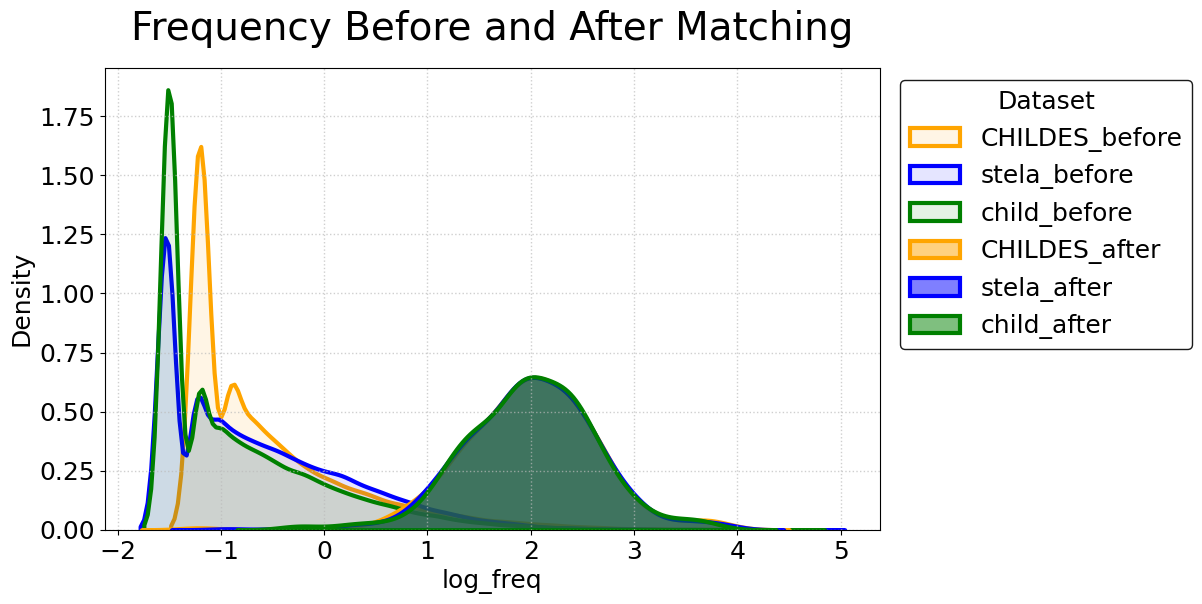

<Figure size 1200x600 with 0 Axes>

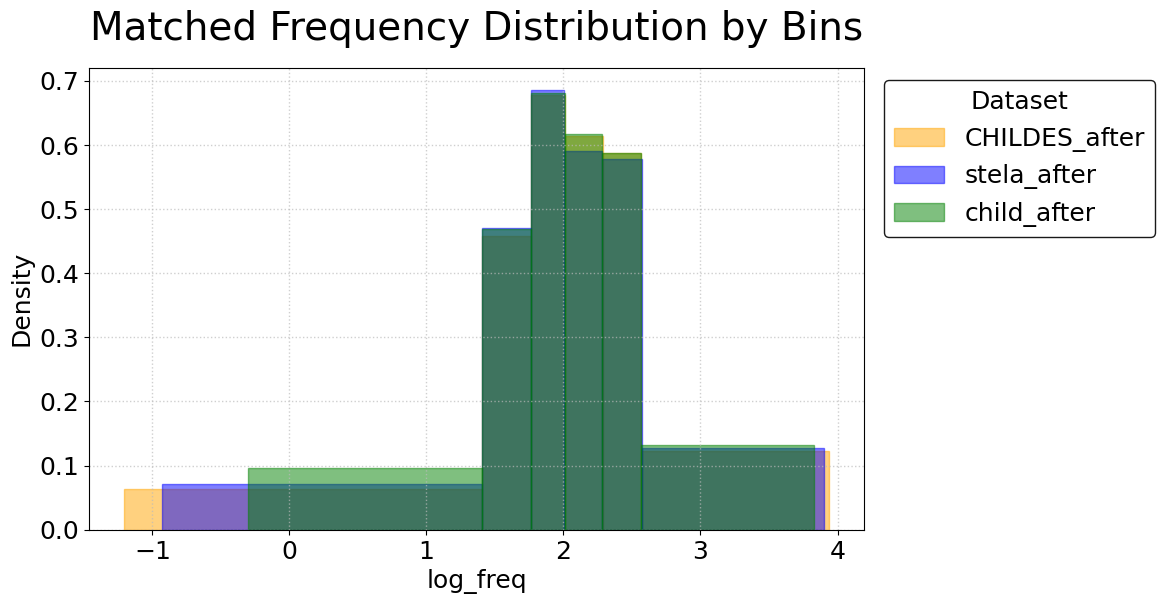

<Figure size 1200x600 with 0 Axes>

In [100]:
# load file
sampling_ratio = 1

file_root = Path(f"{data_root}/CDI_{sampling_ratio}")
freq_root = Path(f"{data_root}/word_freq")
cdi_path = Path(f"{data_root}/cdi_ws_na_childes.csv")
compare_freq(file_root, freq_root, cdi_path, output_dir=None)

# test CDI thresholds

In [243]:
def calculate_stat(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    # Group by x_col and calculate statistics
    stats = df.groupby(x_col)[y_col].agg([("mean", "mean"), ("std", "std"), ("count", "count")]).reset_index()
    # Calculate 95% confidence interval
    stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    return stats


def plot_combined_cdi_curves(human_cdi_path: Path, threshold_path: Path) -> plt.Figure:
    """Plot human CDI development and threshold curves in the same figure."""
    # Create single figure
    fig, ax = plt.subplots(figsize=PlotSettings.DEFAULTS["figsize"])

    # First plot the threshold curves
    df_threshold = pd.read_csv(threshold_path)
    threshold_cols = [col for col in df_threshold.columns if col.startswith("threshold_")]

    threshold_colors = PlotSettings.get_color_palette(len(threshold_cols))

    # Plot threshold curves
    for threshold, color in zip(threshold_cols, threshold_colors):
        stats = calculate_stat(df_threshold, "month", threshold)
        threshold_value = threshold.split("_")[1]

        ax.plot(stats["month"], stats["mean"], label=f"threshold {threshold_value}", color=color, linewidth=PlotSettings.DEFAULTS["linewidth"], linestyle="--")

        ax.fill_between(stats["month"], stats["mean"] - stats["ci"], stats["mean"] + stats["ci"], alpha=0.1, color=color)

    # Plot human CDI development
    df_human = pd.read_csv(human_cdi_path)
    month_cols = [col for col in df_human.columns if (str(col).strip().isnumeric() and int(str(col).strip()) >= 16 and int(str(col).strip()) <= 30)]
    month_cols.sort(key=lambda x: int(x))

    monthly_means = df_human[month_cols].mean()
    monthly_std = df_human[month_cols].std()
    months = [int(col) for col in month_cols]

    # Plot human data
    human_color = "#FF0000"  # Red for human data
    ax.plot(months, monthly_means.values, linewidth=PlotSettings.DEFAULTS["linewidth"], color=human_color, marker="o", label="Human CDI", linestyle="-")

    # Add human confidence interval
    ci = 1.96 * monthly_std / np.sqrt(len(df_human))
    ax.fill_between(months, monthly_means - ci, monthly_means + ci, alpha=0.2, color=human_color)

    # Apply styling
    ax.set_xlabel("Month", fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    ax.set_ylabel("CDI Score", fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    ax.legend(
        fontsize=PlotSettings.DEFAULTS["label_fontsize"], bbox_to_anchor=(1.05, 1), loc="upper left", title="Data Sources", title_fontsize=PlotSettings.DEFAULTS["label_fontsize"]
    )

    # Apply PlotSettings style
    PlotSettings.apply_style_to_axis(ax, "CDI count-threshold")

    plt.tight_layout()
    return fig


# Core metrics

In [8]:
# load and merge stat in different conditions
def load_df(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Load and aggregate data based on metric while handling duplicates."""
    # Filter temperature
    df = df[df["temp"] == 1.0].copy()

    # Create condition column if not exists
    if "condition" not in df.columns:
        df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    if metric != "CDI":
        # First handle null values appropriately
        df[metric] = df[metric].fillna(method="ffill")

        # Group by month and condition to handle duplicates
        df = (
            df.groupby(["condition", metric]).agg({"dataset": "first", "model_type": "first", "temp": "first", "word_num": "mean", "chunk": "first", "month": "last"}).reset_index()
        )

    return df


def calculate_statistics(df: pd.DataFrame, group_header: str, x_header: str, y_header: str) -> pd.DataFrame:
    """Calculate mean, standard deviation, and confidence intervals."""
    stats = df.groupby([group_header, x_header])[y_header].agg(["mean", "std", "count"]).reset_index()

    # Calculate 95% confidence interval
    stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    return stats


def plot_condition_curve(subset: pd.DataFrame, condition: str, x_header: str, plot_settings: PlotSettings) -> None:
    """Plot curve for a single condition with confidence interval."""
    # load files
    color_dict = plot_settings.COLORS
    plt.plot(
        subset[x_header],
        subset["mean"],
        label=condition,
        color=color_dict[condition.split("(")[0]],
        linestyle=plot_settings.LINESTYLES.get(extract_style(condition), "-"),
        linewidth=plot_settings.DEFAULTS["linewidth"],
    )
    plt.fill_between(subset[x_header], subset["mean"] - subset["ci"], subset["mean"] + subset["ci"], color=color_dict[condition.split("(")[0]], alpha=0.2)


def plot_curves(df: pd.DataFrame, x_header: str, y_header: str, group_header: str, y_lim: list[float] = [0, 1]) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    # Initial plot configuration
    PlotSettings.configure_plot()

    # Calculate statistics
    df_stats = calculate_statistics(df, group_header, x_header, y_header)
    # Get unique conditions and their color mapping
    unique_conditions = df_stats[group_header].unique()
    # Plot each condition
    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_curve(subset, condition, x_header, PlotSettings)

    # Configure plot aesthetics
    plt.ylim(y_lim)
    plt.xlabel(x_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    PlotSettings.configure_legend()
    plt.show()

In [15]:
def plot_all_metrics(raw_data_path: str):
    # load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()
    # Sort by month and combine dataset + model_type for labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    x_header = "month"
    group_header = "condition"

    metric_dict = {"type_token_ratio": [0, 1], "rej_type_rate": [0, 0.4], "rej_token_rate": [0, 0.3], "CDI": [0, 1]}
    for metric, ylim in metric_dict.items():
        sel_df = load_df(df, metric=metric)
        plot_curves(sel_df, x_header, metric, group_header, y_lim=ylim)


# Temperature trade-off 

In [95]:
DataFrameType = pd.DataFrame
MetricType = dict[str, list[float]]


class TemperatureTradeoff:
    """Analysis of temperature effects on model performance."""

    def __init__(self, raw_data_path: Path | str):
        """Initialize temperature analysis.

        Args:
            raw_data_path: Path to raw data file
        """
        self.raw_data_path = Path(raw_data_path)
        self.raw_data = pd.read_csv(self.raw_data_path)

        # Define metrics and their y-axis limits
        self.metrics: MetricType = {
            "type_token_ratio": [0, 1],
            "rej_type_rate": [0, 0.4],
            "rej_token_rate": [0, 0.3],
        }

    def load_temperature_data(self, metric: str) -> DataFrameType:
        """Load and aggregate data for temperature analysis."""
        df = self.raw_data.copy()

        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

        # Calculate means across months for each condition and temperature
        grouped_df = (
            df.groupby(["condition", "temp"])
            .agg(
                {
                    metric: "mean",
                    "CDI": "mean",
                }
            )
            .reset_index()
        )

        return grouped_df

    def create_scatter_plot(self, df: DataFrameType, x_metric: str, y_metric: str, y_lim: list[float], output_path: Path | None = None, title: str | None = None) -> None:
        """Create scatter plot with temperature annotations."""
        plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])
        # Plot for each condition
        for condition in df["condition"].unique():
            self._plot_condition(df, condition, x_metric, y_metric)

        # Configure plot
        self._configure_plot(x_metric, y_metric, y_lim, title, output_path)

    def _plot_condition(self, df: DataFrameType, condition: str, x_metric: str, y_metric: str) -> None:
        """Plot data for a single condition."""
        subset = df[df["condition"] == condition]
        base_condition = condition.split("(")[0]
        color = PlotSettings.COLORS.get(base_condition, "gray")
        linestyle = PlotSettings.LINESTYLES.get(extract_style(condition), "-")

        # Plot scatter points
        plt.scatter(subset[x_metric], subset[y_metric], color=color, label=condition, alpha=0.7, s=100)

        # Add temperature annotations
        for _, row in subset.iterrows():
            plt.annotate(f"{row['temp']:.1f}", (row[x_metric], row[y_metric]), xytext=(10, 5), textcoords="offset points", fontsize=10, color=color)

        # Connect points if multiple exist
        if len(subset) > 1:
            plt.plot(subset[x_metric], subset[y_metric], color=color, linestyle=linestyle, alpha=0.5)

    def _configure_plot(self, x_metric: str, y_metric: str, y_lim: list[float], title: str | None, output_path: Path | None) -> None:
        """Configure plot settings."""
        plt.xlabel(x_metric, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.ylabel(y_metric, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.ylim(y_lim)
        plt.xlim([0, 0.5])

        if title:
            plt.title(title, fontsize=PlotSettings.DEFAULTS["title_fontsize"], pad=20)

        PlotSettings.configure_legend()
        plt.tight_layout()

        if output_path:
            plt.savefig(output_path, bbox_inches="tight", dpi=300)
            plt.close()
        else:
            plt.show()

    def analyze_all_metrics(self, output_dir: Path | None = None, base_title: str | None = None) -> None:
        """Analyze all metrics against CDI score."""
        # Create output directory if needed
        if output_dir:
            output_dir = Path(output_dir)
            output_dir.mkdir(parents=True, exist_ok=True)

        # Analyze each metric
        for metric, y_lim in self.metrics.items():
            # Load and process data
            df = self.load_temperature_data(metric)

            # Create plot
            title = f"{base_title} - {metric}" if base_title else metric
            output_path = (output_dir / f"temp_tradeoff_{metric}.png") if output_dir else None

            self.create_scatter_plot(df=df, x_metric="CDI", y_metric=metric, y_lim=y_lim, output_path=output_path, title=title)


def analyze_temperature_effects(data_path: Path | str, output_dir: Path | str | None = None, base_title: str | None = None) -> None:
    """Run temperature trade-off analysis."""
    analysis = TemperatureTradeoff(data_path)
    analysis.analyze_all_metrics(output_dir=Path(output_dir) if output_dir else None, base_title=base_title)


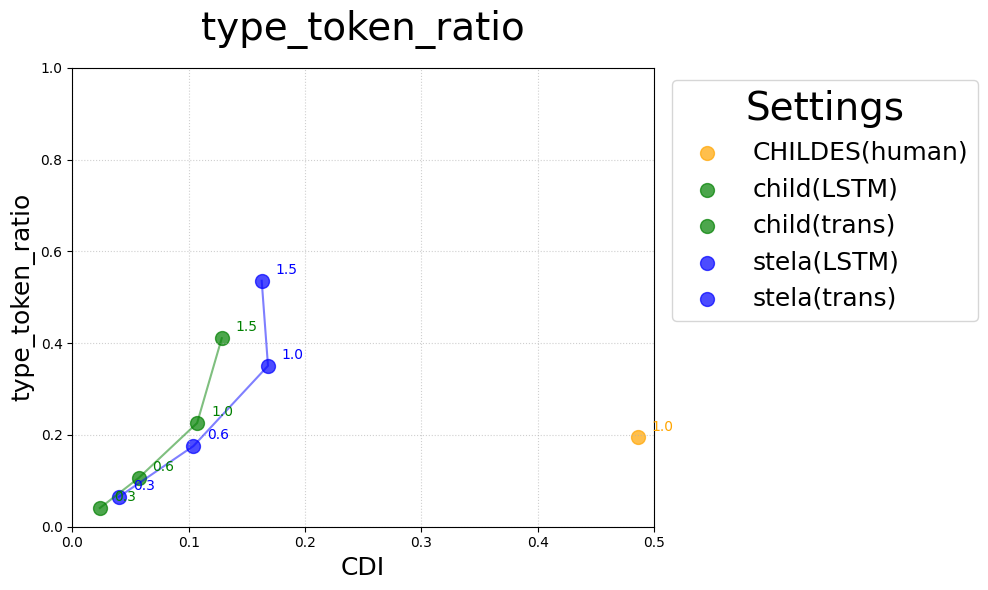

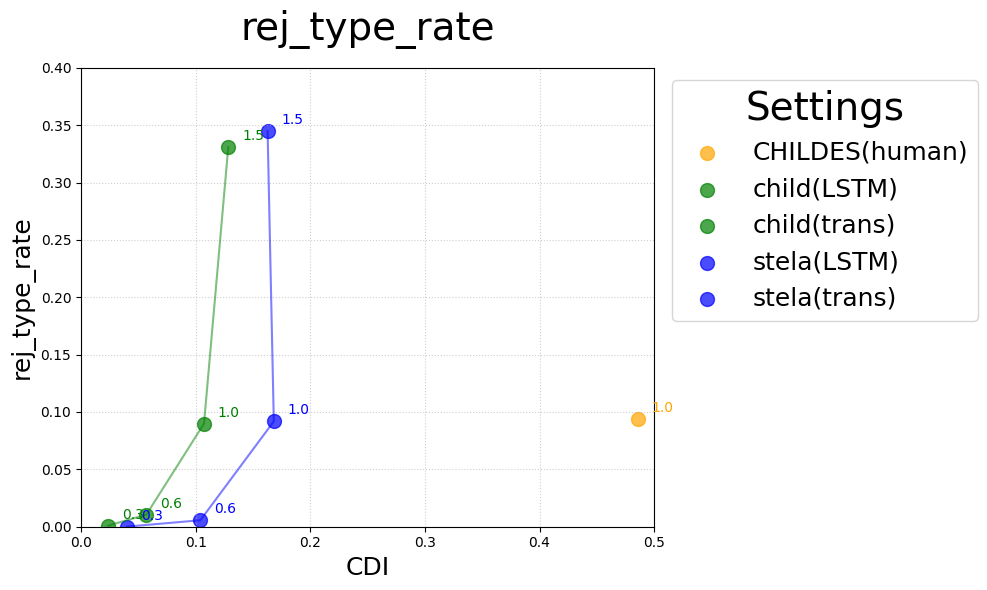

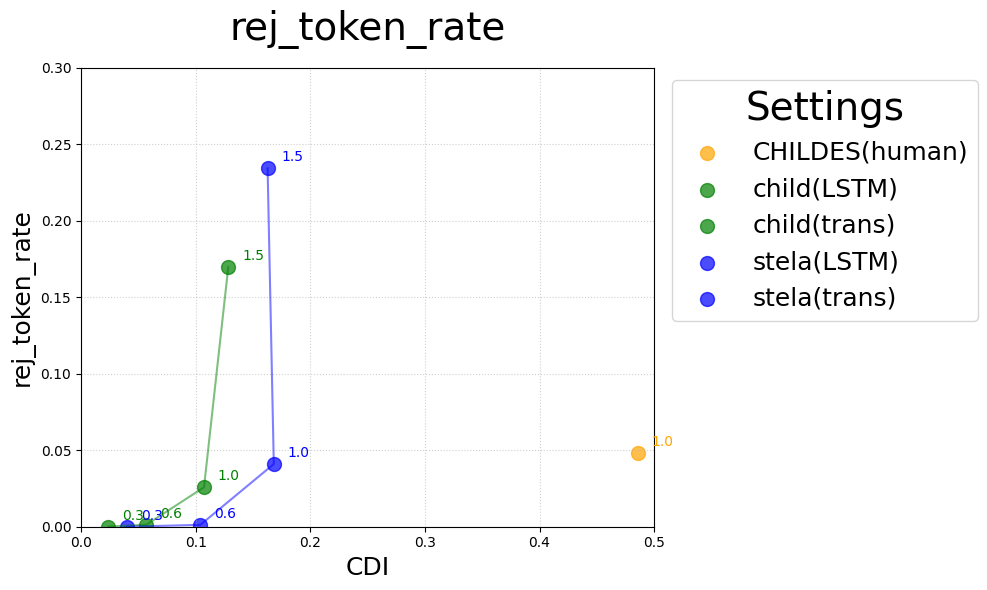

In [96]:
sampling_ratio = 1
raw_data_path = f"{data_root}/CDI_{sampling_ratio}/metric_1000_4.csv"
# plot_all_metrics(raw_data_path)

analyze_temperature_effects(data_path=raw_data_path, output_dir=None)

# Extrapolated metrics

In [ ]:
class SigmoidExtrapolation:
    """Sigmoid curve fitting and extrapolation analysis."""

    def __init__(self, x_data: list[float], y_data: list[float], target_y: float):
        """Initialize with data and target value."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)
        self.target_y = target_y
        self.params: dict[str, t.Any] = {}

    def sigmoid(self, x: np.ndarray, k: float, x0: float) -> np.ndarray:
        """Compute normalized sigmoid function."""
        return 1 / (1 + np.exp(-k * (x - x0)))

    def fit_sigmoid(self) -> dict[str, float]:
        """Fit sigmoid curve and find target value."""
        # Initial parameter estimation
        y_mid = (max(self.y_data) - min(self.y_data)) / 2 + min(self.y_data)
        x0_init = self.x_data[np.argmin(np.abs(self.y_data - y_mid))]

        mid_idx = np.argmin(np.abs(self.x_data - x0_init))
        if mid_idx > 0 and mid_idx < len(self.x_data) - 1:
            dy = self.y_data[mid_idx + 1] - self.y_data[mid_idx - 1]
            dx = self.x_data[mid_idx + 1] - self.x_data[mid_idx - 1]
            k_init = (dy / dx) * 4
        else:
            k_init = 0.1

        # Fit curve
        p0 = [k_init, x0_init]
        bounds = (
            (0.001, 2.0),
            (min(self.x_data), max(self.x_data) * 1.5),
        )

        popt, _ = curve_fit(self.sigmoid, self.x_data, self.y_data, p0=p0, bounds=bounds, maxfev=100000, method="trf")

        # Generate fitted points
        x_fit = np.linspace(0, max(self.x_data), 100)
        y_fit = self.sigmoid(x_fit, *popt)

        # Extrapolate if needed
        if max(self.y_data) < self.target_y:
            x_fit, y_fit = self._extrapolate_to_target(x_fit, y_fit, popt)

        # Find target point
        target_y_index = np.argmin(np.abs(y_fit - self.target_y))
        target_x = x_fit[target_y_index]

        self.params = {"x_fit": x_fit, "y_fit": y_fit, "target_x": target_x, "k": popt[0], "x0": popt[1]}

        return {"target_x": target_x, "k": popt[0], "x0": popt[1]}

    def _extrapolate_to_target(self, x_fit: np.ndarray, y_fit: np.ndarray, popt: tuple[float, float]) -> tuple[np.ndarray, np.ndarray]:
        """Extrapolate fitted curve to reach target value."""
        while y_fit[-1] < self.target_y:
            next_x = x_fit[-1] + (x_fit[1] - x_fit[0])
            x_fit = np.append(x_fit, next_x)
            y_fit = np.append(y_fit, self.sigmoid(next_x, *popt))

            if y_fit[-1] >= self.target_y or len(x_fit) > 1000:
                break

        return x_fit, y_fit

    def plot_curve(self, title: str = "Sigmoid Curve with Extrapolation", output_path: Path | None = None) -> None:
        """Plot the fitted sigmoid curve with extrapolation."""
        if not self.params:
            self.fit_sigmoid()

        plt.figure(figsize=(12, 8))

        # Plot original data
        plt.scatter(self.x_data, self.y_data, color="blue", alpha=0.5, label="Original Data")

        # Plot fitted curve
        plt.plot(self.params["x_fit"], self.params["y_fit"], "r-", label="Fitted Curve", linewidth=2)

        # Plot target line and point
        plt.axhline(y=self.target_y, color="green", linestyle="--", alpha=0.5, label=f"Target Value ({self.target_y:.2f})")
        plt.scatter(self.params["target_x"], self.target_y, color="green", marker="*", s=200, label=f"Target Point (x={self.params['target_x']:.2f})")

        # Configure plot
        plt.grid(True, linestyle=":")
        plt.title(title, fontsize=14)
        plt.xlabel("X Value", fontsize=12)
        plt.ylabel("Y Value", fontsize=12)
        plt.legend(fontsize=10)
        plt.ylim(-0.1, 1.1)

        if output_path:
            plt.savefig(output_path, bbox_inches="tight", dpi=300)
            plt.close()
        else:
            plt.show()


In [31]:
class SigmoidFitter:
    """Fit and plot sigmoid curves with extrapolation to target value."""

    def __init__(self, x_data: list[float], y_data: list[float], target_y: float) -> None:
        """Initialize the sigmoid fitter with data and target."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)
        self.target_y = target_y
        self.params: dict[str, t.Any] = {}

    def sigmoid(self, x: np.ndarray, k: float, x0: float) -> np.ndarray:
        """
        Compute normalized sigmoid function: 1/(1 + exp(-k*(x-x0)))

        Args:
            x: Input values
            k: Steepness of the curve
            x0: x-value of sigmoid midpoint
        Returns:
            y: Values in range [0,1]
        """
        return 1 / (1 + np.exp(-k * (x - x0)))

    def estimate_initial_params(self) -> tuple[list[float], tuple[tuple[float, float], ...]]:
        """Estimate initial parameters and bounds for curve fitting."""
        # Estimate x0 (midpoint)
        y_mid = (max(self.y_data) - min(self.y_data)) / 2 + min(self.y_data)
        x0_init = self.x_data[np.argmin(np.abs(self.y_data - y_mid))]

        # Estimate k (steepness)
        mid_idx = np.argmin(np.abs(self.x_data - x0_init))
        if mid_idx > 0 and mid_idx < len(self.x_data) - 1:
            dy = self.y_data[mid_idx + 1] - self.y_data[mid_idx - 1]
            dx = self.x_data[mid_idx + 1] - self.x_data[mid_idx - 1]
            k_init = (dy / dx) * 4  # Scale factor for sigmoid shape
        else:
            k_init = 0.1

        # Initial parameter guesses
        p0 = [k_init, x0_init]

        # Parameter bounds
        bounds = (
            (0.001, 2.0),  # k bounds: shallow to steep
            (min(self.x_data), max(self.x_data) * 1.5),  # x0 bounds
        )

        return p0, bounds

    def fit_sigmoid(self) -> dict[str, float]:
        """Fit sigmoid and find target x value."""
        # Get initial parameters and bounds
        p0, bounds = self.estimate_initial_params()

        # Fit sigmoid curve with bounds and initial guesses
        popt, _ = curve_fit(self.sigmoid, self.x_data, self.y_data, p0=p0, bounds=bounds, maxfev=100000, method="trf")

        # Generate fitted points with finer resolution
        x_fit = np.linspace(0, max(self.x_data), 100)
        y_fit = self.sigmoid(x_fit, *popt)

        # Extrapolate if needed
        if max(self.y_data) < self.target_y:
            while y_fit[-1] < self.target_y:
                next_x = x_fit[-1] + (x_fit[1] - x_fit[0])
                x_fit = np.append(x_fit, next_x)
                y_fit = np.append(y_fit, self.sigmoid(next_x, *popt))

                if y_fit[-1] >= self.target_y or len(x_fit) > 1000:
                    break

        # Find target point
        target_y_index = np.argmin(np.abs(y_fit - self.target_y))
        target_x = x_fit[target_y_index]

        self.params = {"x_fit": x_fit, "y_fit": y_fit, "target_x": target_x, "k": popt[0], "x0": popt[1]}

        return {"target_x": target_x, "k": popt[0], "x0": popt[1]}

    def plot_curve(self, title: str = "Sigmoid Curve with Extrapolation", output_path: Path | None = None) -> None:
        """Plot the fitted sigmoid curve with extrapolation."""
        if not self.params:
            self.fit_sigmoid()

        plt.figure(figsize=(12, 8))

        # Plot original data points
        plt.scatter(self.x_data, self.y_data, color="blue", alpha=0.5, label="Original Data")

        # Plot fitted curve
        plt.plot(self.params["x_fit"], self.params["y_fit"], "r-", label="Fitted Curve", linewidth=2)

        # Plot target line and point
        plt.axhline(y=self.target_y, color="green", linestyle="--", alpha=0.5, label=f"Target Value ({self.target_y:.2f})")
        plt.scatter(self.params["target_x"], self.target_y, color="green", marker="*", s=200, label=f"Target Point (x={self.params['target_x']:.2f})")

        # Customize plot
        plt.grid(True, linestyle=":")
        plt.title(title, fontsize=14)
        plt.xlabel("X Value", fontsize=12)
        plt.ylabel("Y Value", fontsize=12)
        plt.legend(fontsize=10)
        plt.ylim(-0.1, 1.1)  # Set y-axis limits to show full [0,1] range

        plt.tight_layout()
        if output_path:
            plt.savefig(output_path, bbox_inches="tight", dpi=300)
            plt.close()
        else:
            plt.show()
